In [1]:
import numpy as np

import bot
import state
import physics
import nn
import scoring
import curling_nn
import data_generation
from constants import center_of_target_house, house_outer_circle_radius, STONE_RADIUS_M
import dataset


import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
neural_network = curling_nn.ValueNetwork(seed=0, num_stones=9, hidden_layer_size=100)
loss_function = nn.SoftmaxCrossEntropyLoss()

In [3]:
# TODO: training data should have throws from both teams
seed_states = data_generation.random_sheet_states(
    team1=5,
    team2=4,
    num_sims=1000,
)
num_stones_per_side = 5
team = 1
rng = np.random.default_rng(0)

random_throws, random_states = bot.RandomThrows(
    rng=rng, n_throws_to_generate=1
).get_throws_for_num_sims(team=team, sheet_states=seed_states)

scored_throws, scored_states = data_generation.sample_throws_by_score_for_sheets(
    sheet_states=seed_states,
    team=team,
    throw_searcher=bot.ThrowsGridSearcher(10, 10, 4),
    n_per_score=30,
    rng=rng,
)

throws, states = data_generation.combine_throw_datasets(
    (random_throws, random_states),
    (scored_throws, scored_states),
)

final_states = physics.run_until_stopping(
    sheet_states=state.add_stones_from_throws(states, throws)
)
final_scores = scoring.get_net_score_for_team(final_states, 0)

data = curling_nn.InputFeatures.create_score_match_dataset_from_sheet_states(
    states, throws, final_scores, num_stones_per_side
)
print(f"dataset size: {data.size()}")

dataset size: 121644


In [4]:
data, validation_data = data.partition(0.2, seed=0)

## categorical score predictor

In [5]:
losses = []
val_losses = []
num_points_per_batch = 100
num_iters = 30

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )
    val_losses.append(
        neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
    )

In [6]:
import constants

curling_nn.write_weights(
    constants.value_network_weights_path,
    neural_network,
    data.normalizer,
)
print(f"wrote weights to {constants.value_network_weights_path}")

wrote weights to /home/kzhu/curling/value_network_weights.npz


In [7]:
validation_pred = nn.softmax(neural_network.run(validation_data.input_features[:,:,None]))

In [8]:
validation_r2 = (
    1
    - ((validation_data.answers - validation_pred[:, :, 0]) ** 2).sum()
    / (validation_data.answers**2).sum()
)

In [9]:
validation_r2

np.float64(0.3927850274557143)

Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.


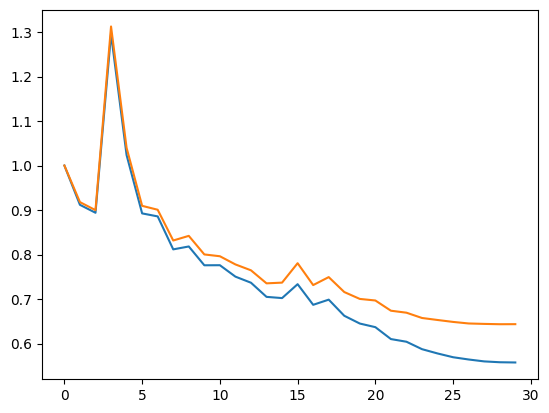

In [10]:
plt.plot(np.array(losses) / losses[0])
plt.plot(np.array(val_losses) / val_losses[0])

In [11]:
validation_loss = neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
print(validation_loss)

1.2337595873339706


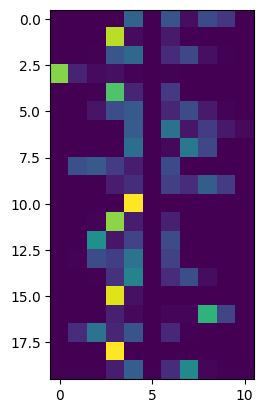

In [12]:
plt.imshow(validation_pred[:20,:,0])

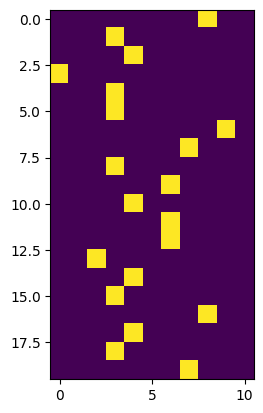

In [13]:
plt.imshow(validation_data.answers[:20,:])

In [234]:
pred_scores = neural_network.expected_score(neural_network.run(validation_data.input_features[:,:,None]))
actual_scores = (validation_data.answers * np.arange(-5,6).reshape((1,11))).sum(axis=1)

expected_score_val_r2 = 1 - ((actual_scores - pred_scores) ** 2).sum() / (actual_scores ** 2).sum()

frac_max_prob_eq_actual = (validation_pred.argmax(axis=1).flatten() == validation_data.answers.argmax(axis=1).flatten()).mean()
print(f"expected_score_val_r2 = {expected_score_val_r2}, frac max prob = actual {frac_max_prob_eq_actual}")

expected_score_val_r2 = 0.8274895115689724, frac max prob = actual 0.835


In [238]:
(1 - (actual_scores - pred_scores) ** 2 / actual_scores ** 2).std() / 200

np.float64(0.00684872830947015)

In [237]:
len(actual_scores) ** .5

200.0

## NEXT UP: predicting from second to last state

In [209]:
20x20
expected score val r^2 0.79ish

30x30
expected_score_val_r2 = 0.8060334892941788, frac max prob = actual 0.834925
extra layer
expected_score_val_r2 = 0.7993249671623189, frac max prob = actual 0.8349
100x100
expected_score_val_r2 = 0.8282151091910064, frac max prob = actual 0.83515
20x20 with new features
expected_score_val_r2 = 0.8044039307457008, frac max prob = actual 0.82885
100x100 with new features
expected_score_val_r2 = 0.8274895115689724, frac max prob = actual 0.835
100x100 with new features and 30 training iters


SyntaxError: invalid decimal literal (5022038.py, line 1)